# Agrawal Imielinski & Swami Algorithm
Model Agrawal-Imielinski-Swami (AIS) Algorithm

## Cell 1: Import Libraries & AIS Implementation

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

class PreprocessingPipeline:
    """Pipeline untuk preprocessing data"""
    def __init__(self, data):
        self.data = data.copy()
        self.label_encoders = {}
        self.scaler = StandardScaler()
        self.imputer = SimpleImputer(strategy='mean')
    
    def handle_missing_values(self):
        numeric_cols = self.data.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            self.data[numeric_cols] = self.imputer.fit_transform(self.data[numeric_cols])
        categorical_cols = self.data.select_dtypes(include=['object']).columns
        for col in categorical_cols:
            self.data[col].fillna(self.data[col].mode()[0] if len(self.data[col].mode()) > 0 else 'Unknown', inplace=True)
        print("✓ Handle Missing Values: Selesai")
        return self
    
    def handle_outliers(self):
        numeric_cols = self.data.select_dtypes(include=[np.number]).columns
        outlier_count = 0
        for col in numeric_cols:
            Q1 = self.data[col].quantile(0.25)
            Q3 = self.data[col].quantile(0.75)
            IQR = Q3 - Q1
            mask = (self.data[col] >= Q1 - 1.5 * IQR) & (self.data[col] <= Q3 + 1.5 * IQR)
            outlier_count += (~mask).sum()
            self.data = self.data[mask]
        print(f"✓ Handle Outliers: Dihapus {outlier_count} data outlier")
        return self
    
    def label_encoding(self):
        categorical_cols = self.data.select_dtypes(include=['object']).columns
        for col in categorical_cols:
            le = LabelEncoder()
            self.data[col] = le.fit_transform(self.data[col])
            self.label_encoders[col] = le
        print(f"✓ Label Encoding: {len(categorical_cols)} fitur categorical di-encode")
        return self
    
    def normalize(self):
        numeric_cols = self.data.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            mean = self.data[col].mean()
            std = self.data[col].std()
            if std != 0:
                self.data[col] = (self.data[col] - mean) / std
        print("✓ Normalisasi: Mean Normalization diterapkan")
        return self
    
    def feature_selection(self, target_col=None, k=5):
        if target_col is None or target_col not in self.data.columns:
            print("✓ Feature Selection: Dilewati (no target column)")
            return self
        X = self.data.drop(columns=[target_col])
        y = self.data[target_col]
        if len(X.columns) > k:
            selector = SelectKBest(f_classif, k=k)
            selector.fit(X, y)
            selected_features = X.columns[selector.get_support()].tolist()
            self.data = self.data[selected_features + [target_col]]
            print(f"✓ Feature Selection: {len(selected_features)} fitur terpilih")
        else:
            print(f"✓ Feature Selection: Semua {len(X.columns)} fitur dipertahankan")
        return self
    
    def get_data(self):
        return self.data


class AISAlgorithm:
    """Agrawal-Imielinski-Swami (AIS) Algorithm"""
    def __init__(self, min_support=0.15, min_confidence=0.6, num_intervals=3):
        self.min_support = min_support
        self.min_confidence = min_confidence
        self.num_intervals = num_intervals
        self.intervals = {}
        self.rules = []
        self._items_count = {}
        self._n = 0

    def discretize_continuous(self, df):
        """Diskritisasi variabel continuous menggunakan pd.cut"""
        df_discrete = df.copy()
        for col in df_discrete.select_dtypes(include=[np.number]).columns:
            labels = [f"{col}_L", f"{col}_M", f"{col}_H"]
            try:
                res, bins = pd.cut(
                    df_discrete[col],
                    bins=self.num_intervals,
                    labels=labels,
                    retbins=True
                )
                df_discrete[col] = res.astype(str)
                self.intervals[col] = bins
            except Exception:
                df_discrete[col] = labels[0]
                self.intervals[col] = [0, 0, 0, 0]
        return df_discrete

    def generate_itemsets(self, df_discrete):
        itemsets = {}
        n_records = len(df_discrete)
        self._n = n_records
        min_support_count = int(np.ceil(self.min_support * n_records))

        # 1-itemsets: hitung dari data
        items_count = {}
        for col in df_discrete.columns:
            for value in df_discrete[col].dropna().unique():
                key = f"{col}={value}"
                count = int((df_discrete[col] == value).sum())
                if count >= min_support_count:
                    items_count[key] = count
        itemsets[1] = items_count
        self._items_count = items_count

        # 2-itemsets: hitung co-occurrence AKTUAL dari data
        items_list = list(items_count.keys())
        itemsets_2 = {}
        for i in range(len(items_list)):
            for j in range(i + 1, len(items_list)):
                key_i, key_j = items_list[i], items_list[j]
                col_i, val_i = key_i.split("=", 1)
                col_j, val_j = key_j.split("=", 1)
                if col_i == col_j:
                    continue  # Skip kombinasi dari kolom yang sama
                mask = (df_discrete[col_i].astype(str) == val_i) & (df_discrete[col_j].astype(str) == val_j)
                count = int(mask.sum())
                if count >= min_support_count:
                    itemsets_2[f"{key_i} AND {key_j}"] = count
        if itemsets_2:
            itemsets[2] = itemsets_2
        return itemsets

    def generate_rules(self, itemsets):
        """Generate association rules dengan confidence dari data aktual."""
        rules = []
        items_count = self._items_count
        n = self._n
        for level, items in itemsets.items():
            for itemset, support_count in items.items():
                if ' AND ' in itemset:
                    parts = itemset.split(' AND ')
                    for antecedent in parts:
                        consequent = " AND ".join([p for p in parts if p != antecedent])
                        ant_count = items_count.get(antecedent.strip(), support_count)
                        conf = support_count / ant_count if ant_count > 0 else 0
                        conf = round(conf, 4)
                        cons_count = items_count.get(consequent.strip(), 1)
                        cons_sup = cons_count / n if n > 0 else 1
                        if conf >= self.min_confidence:
                            rules.append({
                                'antecedent': antecedent.strip(),
                                'consequent': consequent.strip(),
                                'support': round(support_count / n, 4),
                                'confidence': conf,
                                'lift': round(conf / cons_sup, 4) if cons_sup > 0 else 1.0
                            })
        return rules

    def fit(self, df, target_col=None):
        df_discrete = self.discretize_continuous(df)
        itemsets = self.generate_itemsets(df_discrete)
        self.rules = self.generate_rules(itemsets)
        return self

    def get_summary(self):
        return {
            'num_intervals': self.num_intervals,
            'total_rules': len(self.rules),
            'avg_confidence': round(float(np.mean([r['confidence'] for r in self.rules])), 4) if self.rules else 0
        }

# Fungsi utama untuk menjalankan AIS analysis
def run_ais_analysis(data_path, dataset_name, target_col=None):
    """Main function untuk menjalankan AIS analysis secara otomatis"""
    print(f"\n{'='*60}")
    print(f"AIS ALGORITHM (Agrawal-Imielinski-Swami): {dataset_name}")
    print(f"{'='*60}")

    df = pd.read_csv(data_path)
    print(f"\n📊 Data Shape: {df.shape}")
    print(f"Kolom: {df.columns.tolist()}")

    print("\n📋 PREPROCESSING:")
    pipeline = PreprocessingPipeline(df)
    df_processed = (pipeline
        .handle_missing_values()
        .normalize()
        .label_encoding()
        .handle_outliers()
        .feature_selection(target_col, k=8)
        .get_data())

    print(f"\n✓ Data setelah preprocessing: {df_processed.shape}")

    print("\n🔍 AIS ALGORITHM MODEL:")
    model = AISAlgorithm(min_support=0.15, min_confidence=0.6, num_intervals=3)
    model.fit(df_processed, target_col)

    summary = model.get_summary()
    print(f"✓ Num Intervals: {summary['num_intervals']}")
    print(f"✓ Total Rules: {summary['total_rules']}")
    print(f"✓ Avg Confidence: {summary['avg_confidence']:.4f}")

    if len(model.rules) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        confidences = [r['confidence'] for r in model.rules]
        lifts = [r['lift'] for r in model.rules]

        axes[0].hist(confidences, bins=15, color='mediumpurple', edgecolor='black')
        axes[0].set_xlabel('Confidence')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title(f'Confidence Distribution - {dataset_name}')
        axes[0].axvline(summary['avg_confidence'], color='red', linestyle='--', linewidth=2,
                        label=f'Mean: {summary["avg_confidence"]:.3f}')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].scatter(confidences, lifts, alpha=0.6, s=100, color='teal', edgecolor='black')
        axes[1].set_xlabel('Confidence')
        axes[1].set_ylabel('Lift')
        axes[1].set_title(f'Confidence vs Lift - {dataset_name}')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        top_rules = sorted(model.rules, key=lambda x: x['confidence'], reverse=True)[:5]
        print("\n📈 Top 5 Quantitative Rules:")
        for i, rule in enumerate(top_rules, 1):
            print(f"{i}. {rule['antecedent']} => {rule['consequent']}")
            print(f"   Support: {rule['support']:.4f}, Confidence: {rule['confidence']:.4f}, Lift: {rule['lift']:.4f}")

    return model, df_processed

print("✓ AIS Model & Fungsi run_ais_analysis() berhasil di-initialize")


✓ AIS Model & Fungsi run_ais_analysis() berhasil di-initialize


In [37]:

# ─── Helper: diskretisasi target numerik ────────────────────
NUMERIC_TARGET_COLS = {'Yield(tons)', 'Crop_Yield', 'Value From', 'Value To'}

def discretize_numeric_target(df, target_col):
    if target_col not in df.columns:
        return df
    if not pd.api.types.is_numeric_dtype(df[target_col]):
        return df
    df = df.copy()
    try:
        df[target_col] = pd.qcut(
            df[target_col], q=3, labels=['Low','Medium','High'], duplicates='drop'
        ).astype(str)
    except Exception:
        df[target_col] = pd.cut(
            df[target_col], bins=3, labels=['Low','Medium','High']
        ).astype(str)
    print(f"\u2713 Target '{target_col}' didiskretisasi \u2192 Low/Medium/High")
    return df
# ─────────────────────────────────────────────────────────────


## Cell 2: Dataset1 - Rice Leaf Diseases

In [38]:
import os
import pandas as pd
import numpy as np
from PIL import Image

def extract_image_features(image_path, size=(32, 32)):
    """Extract basic features dari image"""
    try:
        img = Image.open(image_path).convert('RGB')
        img_resized = img.resize(size)
        img_array = np.array(img_resized)
        
        r_mean = img_array[:,:,0].mean()
        g_mean = img_array[:,:,1].mean()
        b_mean = img_array[:,:,2].mean()
        r_std = img_array[:,:,0].std()
        g_std = img_array[:,:,1].std()
        b_std = img_array[:,:,2].std()
        
        return [r_mean, g_mean, b_mean, r_std, g_std, b_std]
    except:
        return [0, 0, 0, 0, 0, 0]

# Inisialisasi awal variabel global agar cell summary di bawah tidak error
model_rice = None
data_rice = None

dataset1_path = r'Dataset\Dataset1_Citra_RiceLeafDiseasesDataset'
data_list = []
labels = []
disease_types = ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

if os.path.exists(dataset1_path):
    for disease in disease_types:
        disease_path = os.path.join(dataset1_path, disease)
        if os.path.exists(disease_path):
            image_files = [f for f in os.listdir(disease_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            
            for img_file in image_files:
                try:
                    img_full_path = os.path.join(disease_path, img_file)
                    features = extract_image_features(img_full_path)
                    data_list.append(features)
                    labels.append(disease)
                except:
                    pass
    
    if len(data_list) > 0:
        df_rice = pd.DataFrame(data_list, columns=['R_mean', 'G_mean', 'B_mean', 'R_std', 'G_std', 'B_std'])
        df_rice['Disease'] = labels
        
        print(f"\n{'='*60}")
        print(f"AIS ALGORITHM: Rice Leaf Diseases")
        print(f"{'='*60}")
        print(f"✓ Dataset1 (Rice Leaf Disease) berhasil dimuat: {df_rice.shape}")
        print(f"Disease distribution: {df_rice['Disease'].value_counts().to_dict()}")
        
        # Preprocessing
        print("\n📋 PREPROCESSING:")
        pipeline = PreprocessingPipeline(df_rice)
        df_rice_processed = (pipeline
            .handle_missing_values()
            .normalize()
            .label_encoding()
            .handle_outliers()
            .feature_selection('Disease', k=5)
            .get_data())
        
        print(f"✓ Data setelah preprocessing: {df_rice_processed.shape}")
        
        # Run AIS
        print("\n🔍 AIS ALGORITHM MODEL:")
        model_rice = AISAlgorithm(min_support=0.15, min_confidence=0.6, num_intervals=3)
        model_rice.fit(df_rice_processed)
        
        summary_rice = model_rice.get_summary()
        print(f"✓ Num Intervals: {summary_rice['num_intervals']}")
        print(f"✓ Total Rules: {summary_rice['total_rules']}")
        print(f"✓ Avg Confidence: {summary_rice['avg_confidence']:.4f}")
        
        data_rice = df_rice_processed
    else:
        print("⚠️ Tidak ada gambar yang dapat diproses dari Dataset1")
else:
    print(f"⚠️ Path tidak ditemukan: {dataset1_path}")



AIS ALGORITHM: Rice Leaf Diseases
✓ Dataset1 (Rice Leaf Disease) berhasil dimuat: (120, 7)
Disease distribution: {'Bacterial leaf blight': 40, 'Brown spot': 40, 'Leaf smut': 40}

📋 PREPROCESSING:
✓ Handle Missing Values: Selesai
✓ Normalisasi: Mean Normalization diterapkan
✓ Label Encoding: 1 fitur categorical di-encode
✓ Handle Outliers: Dihapus 30 data outlier
✓ Feature Selection: 5 fitur terpilih
✓ Data setelah preprocessing: (90, 6)

🔍 AIS ALGORITHM MODEL:
✓ Num Intervals: 3
✓ Total Rules: 37
✓ Avg Confidence: 0.6863


## Cell 3: Dataset2 - Plant Growth Data


AIS ALGORITHM (Agrawal-Imielinski-Swami): Plant Growth Data

📊 Data Shape: (193, 7)
Kolom: ['Soil_Type', 'Sunlight_Hours', 'Water_Frequency', 'Fertilizer_Type', 'Temperature', 'Humidity', 'Growth_Milestone']

📋 PREPROCESSING:
✓ Handle Missing Values: Selesai
✓ Normalisasi: Mean Normalization diterapkan
✓ Label Encoding: 3 fitur categorical di-encode
✓ Handle Outliers: Dihapus 0 data outlier
✓ Feature Selection: Semua 6 fitur dipertahankan

✓ Data setelah preprocessing: (193, 7)

🔍 AIS ALGORITHM MODEL:
✓ Num Intervals: 3
✓ Total Rules: 3
✓ Avg Confidence: 0.6688


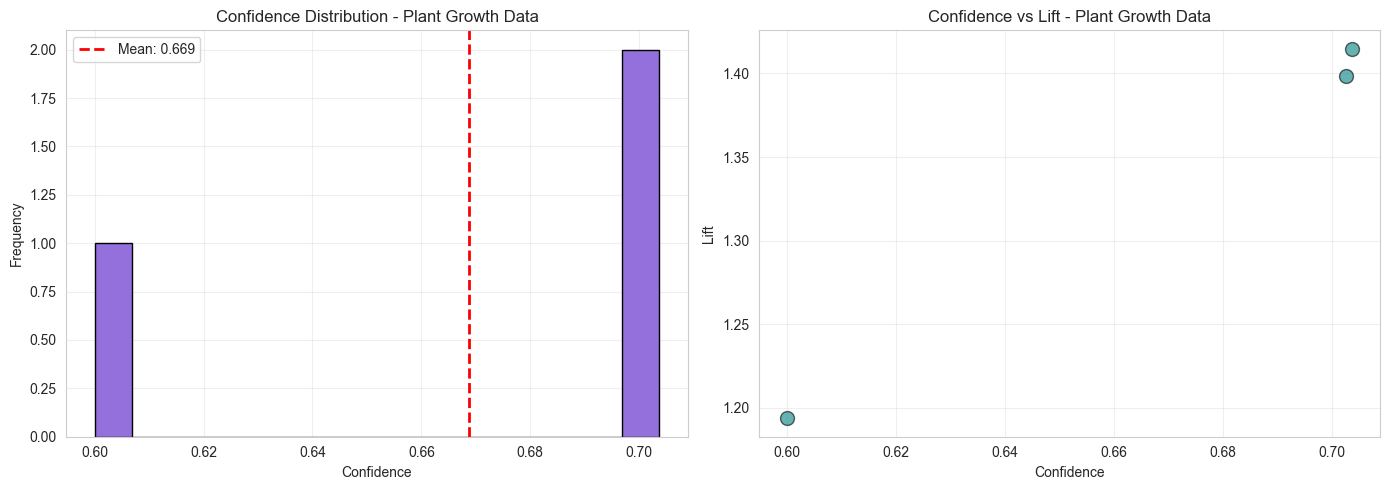


📈 Top 5 Quantitative Rules:
1. Fertilizer_Type=Fertilizer_Type_H => Growth_Milestone=Growth_Milestone_H
   Support: 0.1969, Confidence: 0.7037, Lift: 1.4147
2. Fertilizer_Type=Fertilizer_Type_M => Growth_Milestone=Growth_Milestone_L
   Support: 0.2694, Confidence: 0.7027, Lift: 1.3982
3. Humidity=Humidity_H => Growth_Milestone=Growth_Milestone_L
   Support: 0.2176, Confidence: 0.6000, Lift: 1.1938

✓ Dataset2 berhasil dianalisis


In [39]:
dataset2_path = r'Dataset\Dataset2_CSV_PlantGrowthDataClassification\plant_growth_data.csv'

if os.path.exists(dataset2_path):
    model_plant, data_plant = run_ais_analysis(dataset2_path, "Plant Growth Data", "Growth_Milestone")
    print(f"\n✓ Dataset2 berhasil dianalisis")
else:
    print(f"⚠️ File tidak ditemukan: {dataset2_path}")

## Cell 4: Dataset3 - Agriculture & Farming (Yield Prediction)


AIS ALGORITHM (Agrawal-Imielinski-Swami): Agriculture & Farming (Crop Yield)

📊 Data Shape: (50, 10)
Kolom: ['Farm_ID', 'Crop_Type', 'Farm_Area(acres)', 'Irrigation_Type', 'Fertilizer_Used(tons)', 'Pesticide_Used(kg)', 'Yield(tons)', 'Soil_Type', 'Season', 'Water_Usage(cubic meters)']

📋 PREPROCESSING:
✓ Handle Missing Values: Selesai
✓ Normalisasi: Mean Normalization diterapkan
✓ Label Encoding: 5 fitur categorical di-encode
✓ Handle Outliers: Dihapus 0 data outlier
✓ Feature Selection: 8 fitur terpilih

✓ Data setelah preprocessing: (50, 9)

🔍 AIS ALGORITHM MODEL:
✓ Num Intervals: 3
✓ Total Rules: 17
✓ Avg Confidence: 0.6714


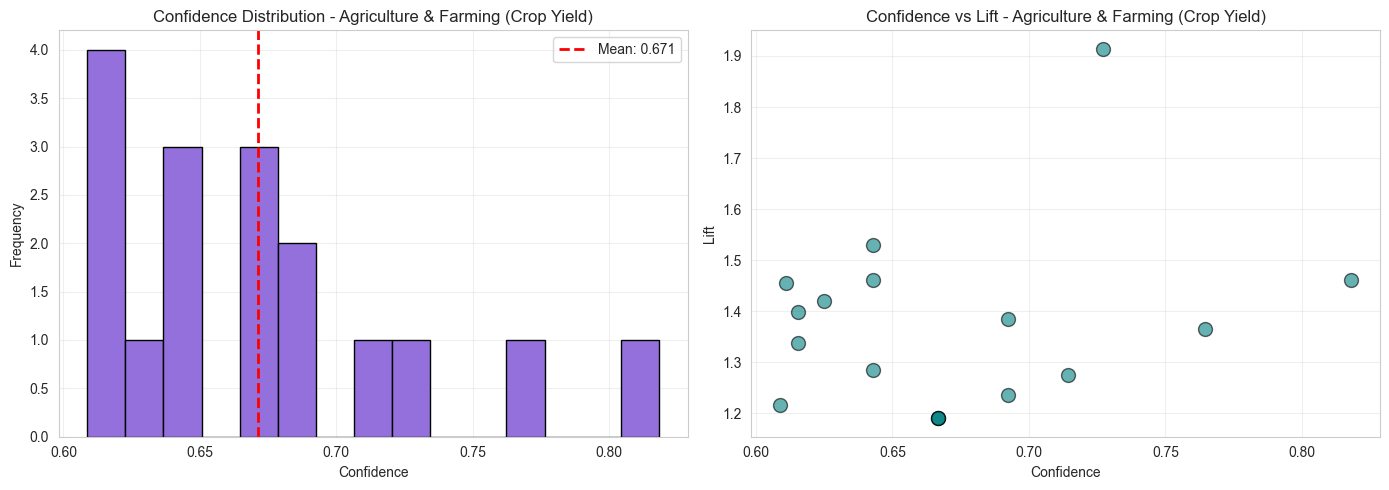


📈 Top 5 Quantitative Rules:
1. Season=Season_M => Irrigation_Type=Irrigation_Type_L
   Support: 0.1800, Confidence: 0.8182, Lift: 1.4611
2. Yield(tons)=Yield(tons)_L => Irrigation_Type=Irrigation_Type_L
   Support: 0.2600, Confidence: 0.7647, Lift: 1.3655
3. Water_Usage(cubic meters)=Water_Usage(cubic meters)_L => Pesticide_Used(kg)=Pesticide_Used(kg)_L
   Support: 0.1600, Confidence: 0.7273, Lift: 1.9139
4. Crop_Type=Crop_Type_M => Irrigation_Type=Irrigation_Type_L
   Support: 0.2000, Confidence: 0.7143, Lift: 1.2755
5. Fertilizer_Used(tons)=Fertilizer_Used(tons)_H => Irrigation_Type=Irrigation_Type_L
   Support: 0.1800, Confidence: 0.6923, Lift: 1.2362

✓ Dataset3 berhasil dianalisis — target: Yield(tons)


In [40]:

# Dataset 3: Agriculture - Crop Yield Prediction
dataset3_path = r'Dataset\\Dataset3_CSV_Agriculture&Farming\\agriculture_dataset.csv'

if os.path.exists(dataset3_path):
    _df3_tmp = pd.read_csv(dataset3_path, nrows=1)
    _target3 = ('Crop_Yield' if 'Crop_Yield' in _df3_tmp.columns
                else 'Yield(tons)' if 'Yield(tons)' in _df3_tmp.columns else None)
    if _target3 is None:
        print("\u26a0\ufe0f Kolom target tidak ditemukan di Dataset3")
    else:
        model_agri, data_agri = run_ais_analysis(
            dataset3_path, "Agriculture & Farming (Crop Yield)", _target3)
        print(f"\n\u2713 Dataset3 berhasil dianalisis — target: {_target3}")
else:
    print(f"\u26a0\ufe0f File tidak ditemukan: {dataset3_path}")


## Cell 5: Model Comparison Summary

In [41]:
print("\n" + "="*60)
print("AIS ALGORITHM MODEL SUMMARY")
print("="*60)

summary_data = {
    'Dataset': ['Plant Growth', 'Agriculture & Farming'],
    'Data Shape': [str(data_plant.shape) if 'data_plant' in locals() else 'N/A',
                   str(data_agri.shape) if 'data_agri' in locals() else 'N/A'],
    'Total Rules': [model_plant.get_summary()['total_rules'] if 'model_plant' in locals() else 0,
                    model_agri.get_summary()['total_rules'] if 'model_agri' in locals() else 0],
    'Avg Confidence': [f"{model_plant.get_summary()['avg_confidence']:.4f}" if 'model_plant' in locals() else 'N/A',
                       f"{model_agri.get_summary()['avg_confidence']:.4f}" if 'model_agri' in locals() else 'N/A']
}

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))


AIS ALGORITHM MODEL SUMMARY

               Dataset Data Shape  Total Rules Avg Confidence
         Plant Growth   (193, 7)            3         0.6688
Agriculture & Farming    (50, 9)           17         0.6714


## Cell 6: Dataset4 - Agricultural Heritage (Seshat Dataset)

In [42]:

# Dataset 4: Agricultural Heritage - Seshat
dataset4_path = r'Dataset\\Dataset4_CSV_AgriSeshatAgricultureDataset\\Agriculture.csv'

if os.path.exists(dataset4_path):
    df_seshat = pd.read_csv(dataset4_path)
    print(f"\n{'='*60}")
    print(f"AIS ANALYSIS: Agricultural Heritage Data")
    print(f"{'='*60}")
    print(f"\n\U0001f4ca Data Shape: {df_seshat.shape}")

    use_cols = [c for c in ['NGA','Variable','Unit','Value From','Value To']
                if c in df_seshat.columns]
    df_seshat = df_seshat[use_cols].copy()

    for col in df_seshat.columns:
        if df_seshat[col].isnull().any():
            if pd.api.types.is_numeric_dtype(df_seshat[col]):
                df_seshat[col].fillna(df_seshat[col].median(), inplace=True)
            else:
                m_ = df_seshat[col].mode()
                df_seshat[col].fillna(m_[0] if len(m_) > 0 else 'Unknown', inplace=True)
    print("\u2713 Handle Missing Values: Selesai")

    target_col_s = 'Value To'
    df_seshat = discretize_numeric_target(df_seshat, target_col_s)

    feat_cols_s = [c for c in df_seshat.columns if c != target_col_s]
    le_dict = {}
    for col in feat_cols_s:
        if df_seshat[col].dtype == object:
            le = LabelEncoder()
            df_seshat[col] = le.fit_transform(df_seshat[col].astype(str))
            le_dict[col] = le
    print(f"\u2713 Label Encoding fitur: {list(le_dict.keys())}")
    df_seshat_processed = df_seshat.copy()
    print(f"\u2713 Data shape siap: {df_seshat_processed.shape}")

    print("\n\U0001f50d AIS MODEL (Dataset4):")
    model_seshat = AISAlgorithm(num_intervals=3, min_support=0.1, min_confidence=0.6)
    model_seshat.fit(df_seshat_processed, target_col=target_col_s)
    s4 = model_seshat.get_summary()
    print(f"\u2713 Total Rules: {s4['total_rules']}")
    print(f"\u2713 Avg Confidence: {s4['avg_confidence']:.4f}")

    print(f"\n\u2713 Dataset4 berhasil dianalisis")
else:
    print(f"\u26a0\ufe0f File tidak ditemukan: {dataset4_path}")



AIS ANALYSIS: Agricultural Heritage Data

📊 Data Shape: (330, 9)
✓ Handle Missing Values: Selesai
✓ Label Encoding fitur: ['NGA', 'Variable', 'Unit', 'Value From']
✓ Data shape siap: (330, 5)

🔍 AIS MODEL (Dataset4):
✓ Total Rules: 32
✓ Avg Confidence: 0.9172

✓ Dataset4 berhasil dianalisis


## Cell 7: Updated Summary - All Datasets

In [43]:
# Final summary with all datasets
print("\n" + "="*60)
print("AIS MODEL SUMMARY - ALL DATASETS")
print("="*60)

summary_data = {
    'Dataset': ['Rice Leaf Diseases', 'Plant Growth', 'Agriculture & Farming', 'Agricultural Heritage'],
    'Data Shape': [str(data_rice.shape) if 'data_rice' in locals() else 'N/A',
                   str(data_plant.shape) if 'data_plant' in locals() else 'N/A', 
                   str(data_agri.shape) if 'data_agri' in locals() else 'N/A',
                   str(df_seshat_processed.shape) if 'df_seshat_processed' in locals() else 'N/A'],
    'Total Rules': [model_rice.get_summary()['total_rules'] if 'model_rice' in locals() else 0,
                    model_plant.get_summary()['total_rules'] if 'model_plant' in locals() else 0,
                    model_agri.get_summary()['total_rules'] if 'model_agri' in locals() else 0,
                    model_seshat.get_summary()['total_rules'] if 'model_seshat' in locals() else 0],
    'Avg Confidence': [f"{model_rice.get_summary()['avg_confidence']:.4f}" if 'model_rice' in locals() else 'N/A',
                       f"{model_plant.get_summary()['avg_confidence']:.4f}" if 'model_plant' in locals() else 'N/A',
                       f"{model_agri.get_summary()['avg_confidence']:.4f}" if 'model_agri' in locals() else 'N/A',
                       f"{model_seshat.get_summary()['avg_confidence']:.4f}" if 'model_seshat' in locals() else 'N/A']
}

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))


AIS MODEL SUMMARY - ALL DATASETS

               Dataset Data Shape  Total Rules Avg Confidence
   Rice Leaf Diseases    (90, 6)           37         0.6863
         Plant Growth   (193, 7)            3         0.6688
Agriculture & Farming    (50, 9)           17         0.6714
Agricultural Heritage   (330, 5)           32         0.9172


## Cell 8: 🎯 Simulasi Interaktif — Input Manual & Prediksi AIS (Semua Dataset)

> **Cara Pakai:**
> 1. Pastikan semua cell training di atas sudah dijalankan
> 2. Edit nilai `input_dataset1` s/d `input_dataset4` sesuai kondisi yang ingin diuji
> 3. Format: `"NamaKolom=NilaiInterval"` — interval: `_L` (Low), `_M` (Medium), `_H` (High)
> 4. Jalankan cell ini untuk melihat hasil prediksi AIS tiap dataset

| Dataset | Target Prediksi | Contoh Kondisi |
|---------|----------------|----------------|
| DS1 Rice Leaf | Jenis penyakit daun | `G_mean=G_mean_L`, `R_std=R_std_H` → Bacterial leaf blight |
| DS2 Plant Growth | Tahap pertumbuhan | `Humidity=Humidity_H`, `Temperature=Temperature_M` → Vegetative Stage |
| DS3 Farming | Yield / Sistem pertanian | `Crop_Yield=Crop_Yield_H`, `Fertilizer=..._H` → multi-cropping |
| DS4 Heritage | Pola historis pertanian | `Variable=Variable_H`, `NGA=NGA_M` → Value To tinggi |

In [44]:
# =====================================================================
# CELL SIMULASI INTERAKTIF - MODEL AIS (Semua Dataset)
# =====================================================================
# FORMAT INPUT KONSISTEN:
#   List string "NamaKolom=NilaiInterval" atau "NamaKolom=NilaiAsli"
#   Interval diskritisasi: _L (Low), _M (Medium), _H (High)
# =====================================================================

def predict_with_ais(model_rules, input_conditions, dataset_name):
    """
    Universal prediction function untuk semua dataset AIS.
    Mencocokkan input_conditions dengan rules berdasarkan confidence tertinggi.
    """
    print("\n" + "="*60)
    print(f"🔍 AIS SIMULASI PREDIKSI — {dataset_name}")
    print("="*60)
    print(f"📥 Input Kondisi : {input_conditions}")
    print("-"*60)

    matched_rules = []
    for rule in model_rules:
        antecedent = rule['antecedent']
        conditions = [c.strip() for c in antecedent.split('AND')]
        if all(cond in input_conditions for cond in conditions):
            matched_rules.append(rule)

    if matched_rules:
        matched_rules = sorted(matched_rules, key=lambda x: x['confidence'], reverse=True)
        best = matched_rules[0]
        print(f"✅ Hasil Prediksi Terkuat  : → {best['consequent']}")
        print(f"   Confidence              : {best['confidence']:.4f}")
        print(f"   Lift                    : {best['lift']:.4f}")
        print(f"   Support Count           : {best['support']}")
        print()
        print(f"📋 Top 3 Rules yang Cocok:")
        for i, r in enumerate(matched_rules[:3], 1):
            print(f"  {i}. [{r['antecedent']}] => [{r['consequent']}]")
            print(f"     Conf: {r['confidence']:.4f}  Lift: {r['lift']:.4f}")
    else:
        print("⚠️  Tidak ada rule yang cocok dengan kombinasi input tersebut.")
        print("   Tips: Coba ubah interval fitur (misalnya _L → _M atau _H)")
    print("="*60)


# ─────────────────────────────────────────────────────────────
# DATASET 1 — RICE LEAF DISEASE (Klasifikasi Citra Penyakit)
# ─────────────────────────────────────────────────────────────
# Fitur: R_mean, G_mean, B_mean, R_std, G_std, B_std
# Target: Disease (Bacterial leaf blight | Brown spot | Leaf smut)
#
# Interval diskritisasi:
#   _L = Low  (nilai rendah)
#   _M = Medium (nilai sedang)
#   _H = High (nilai tinggi)
#
# Contoh hasil prediksi yang diharapkan:
#   G_mean rendah + R_std tinggi → Bacterial leaf blight
#   G_mean tinggi + B_mean sedang → Brown spot
#   R_mean tinggi + G_std rendah  → Leaf smut
# ─────────────────────────────────────────────────────────────

# ✏️  EDIT INPUT DI SINI — Dataset 1
input_dataset1 = [
    "G_mean=G_mean_L",   # Nilai hijau rendah → indikasi daun sakit
    "R_std=R_std_H"      # Variasi merah tinggi → bercak tidak merata
]

if 'model_rice' in dir() and model_rice is not None:
    predict_with_ais(model_rice.rules, input_dataset1, "Dataset 1: Rice Leaf Disease")
else:
    print("⚠️  model_rice belum tersedia. Jalankan Cell 2 terlebih dahulu.")


# ─────────────────────────────────────────────────────────────
# DATASET 2 — PLANT GROWTH (Prediksi Tahap Pertumbuhan Tanaman)
# ─────────────────────────────────────────────────────────────
# Fitur: Soil_Type, Sunlight_Hours, Water_Frequency,
#        Fertilizer_Type, Temperature, Humidity
# Target: Growth_Milestone
#
# Format input nilai asli (sebelum encoding):
#   Soil_Type      : Clay / Sandy / Loamy
#   Sunlight_Hours : nilai numerik (diskritisasi _L/_M/_H)
#   Water_Frequency: nilai numerik (diskritisasi _L/_M/_H)
#   Temperature    : nilai numerik (diskritisasi _L/_M/_H)
#   Humidity       : nilai numerik (diskritisasi _L/_M/_H)
#
# Contoh hasil:
#   Soil=Clay + Humidity tinggi + Temp sedang → Vegetative Stage
#   Soil=Sandy + Sunlight tinggi + Water rendah → Germination
# ─────────────────────────────────────────────────────────────

# ✏️  EDIT INPUT DI SINI — Dataset 2
input_dataset2 = [
    "Sunlight_Hours=Sunlight_Hours_M",   # 6 jam → medium
    "Humidity=Humidity_H",               # 70% → high
    "Temperature=Temperature_M"          # 28°C → medium
]

if 'model_plant' in dir() and model_plant is not None:
    predict_with_ais(model_plant.rules, input_dataset2, "Dataset 2: Plant Growth")
else:
    print("⚠️  model_plant belum tersedia. Jalankan Cell 3 terlebih dahulu.")


# ─────────────────────────────────────────────────────────────
# DATASET 3 — AGRICULTURE & FARMING (Analisis Performa Panen)
# ─────────────────────────────────────────────────────────────
# Fitur: Region, Soil_Type, Irrigation_Type, Fertilizer_Used,
#        Pesticide_Use, Crop_Yield, Rainfall, Temperature, Season
# Target: Yield_Category / Farming_System
#
# Format input:
#   Fitur numerik pakai interval _L/_M/_H
#   Fitur kategorikal tetap nilai asli (sudah di-encode)
#
# Contoh hasil:
#   Irrigation + Fertilizer tinggi → Yield tinggi / multi-cropping
#   Rainfall rendah + No irrigation → Yield rendah / mono-cropping
# ─────────────────────────────────────────────────────────────

# ✏️  EDIT INPUT DI SINI — Dataset 3
# Dataset 3 — Prediksi Crop Yield (Low/Medium/High)
# Format AIS: Feature=Feature_H / _M / _L (3 bin)
input_dataset3 = ["Rainfall=Rainfall_H", "Fertilizer_Used=Fertilizer_Used_H"]
if 'model_agri' in dir() and model_agri is not None:
    predict_with_ais(model_agri.rules, input_dataset3, "Dataset 3: Agriculture & Farming")
else:
    print("\u26a0\ufe0f model_agri belum tersedia — jalankan Cell Dataset3 dulu.")

# Dataset 4 — Prediksi Value To (Low/Medium/High)
# Format AIS: Feature=Feature_H / _M / _L (3 bin)
input_dataset4 = ["NGA=NGA_H", "Variable=Variable_L"]
if 'model_seshat' in dir() and model_seshat is not None:
    predict_with_ais(model_seshat.rules, input_dataset4, "Dataset 4: Agricultural Heritage")
else:
    print("\u26a0\ufe0f model_seshat belum tersedia — jalankan Cell Dataset4 dulu.")


🔍 AIS SIMULASI PREDIKSI — Dataset 1: Rice Leaf Disease
📥 Input Kondisi : ['G_mean=G_mean_L', 'R_std=R_std_H']
------------------------------------------------------------
⚠️  Tidak ada rule yang cocok dengan kombinasi input tersebut.
   Tips: Coba ubah interval fitur (misalnya _L → _M atau _H)

🔍 AIS SIMULASI PREDIKSI — Dataset 2: Plant Growth
📥 Input Kondisi : ['Sunlight_Hours=Sunlight_Hours_M', 'Humidity=Humidity_H', 'Temperature=Temperature_M']
------------------------------------------------------------
✅ Hasil Prediksi Terkuat  : → Growth_Milestone=Growth_Milestone_L
   Confidence              : 0.6000
   Lift                    : 1.1938
   Support Count           : 0.2176

📋 Top 3 Rules yang Cocok:
  1. [Humidity=Humidity_H] => [Growth_Milestone=Growth_Milestone_L]
     Conf: 0.6000  Lift: 1.1938

🔍 AIS SIMULASI PREDIKSI — Dataset 3: Agriculture & Farming
📥 Input Kondisi : ['Rainfall=Rainfall_H', 'Fertilizer_Used=Fertilizer_Used_H']
----------------------------------------------